In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from src.GMM import GMM
from src.Kmeans import KMeans
from src.Dbscan import DBSCAN
from src.PCA import PCA

from src.graficos import ejecutar_kmeans_completo, ejecutar_gmm_completo


In [22]:
data = pd.read_csv('data/clustering.csv', usecols=[1, 2])  # Solo lee columnas A y B
X = data.values  # (N, 2)

In [23]:
#min max scaler
X= (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))

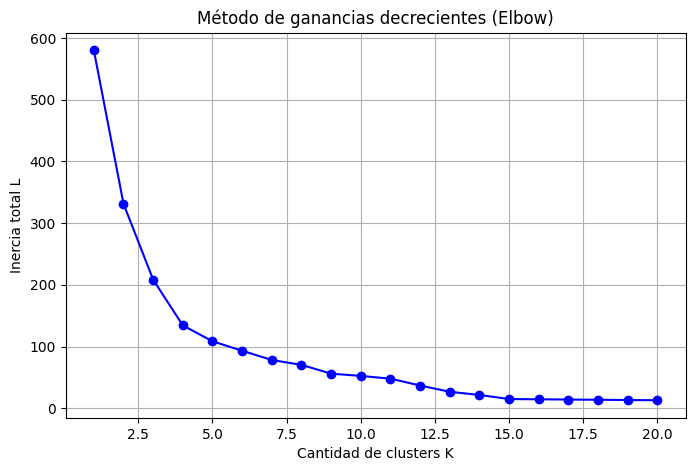

Paso 2: Ejecutando K-means con K = 15...


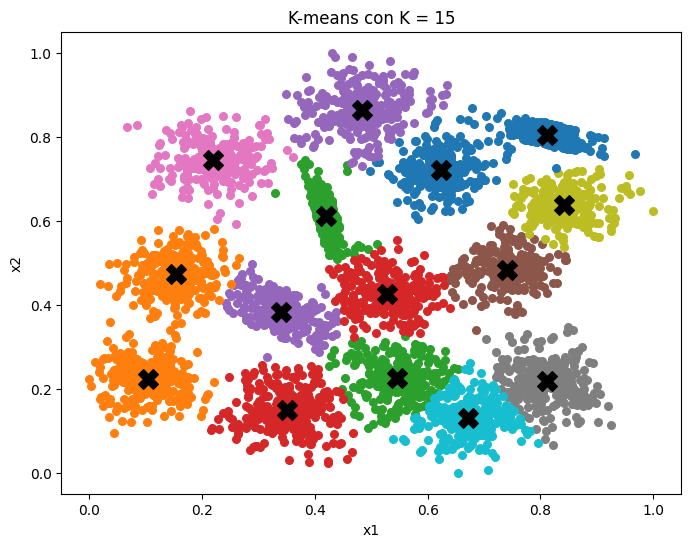

In [5]:
ejecutar_kmeans_completo(X, k_max=20, k_final=15)


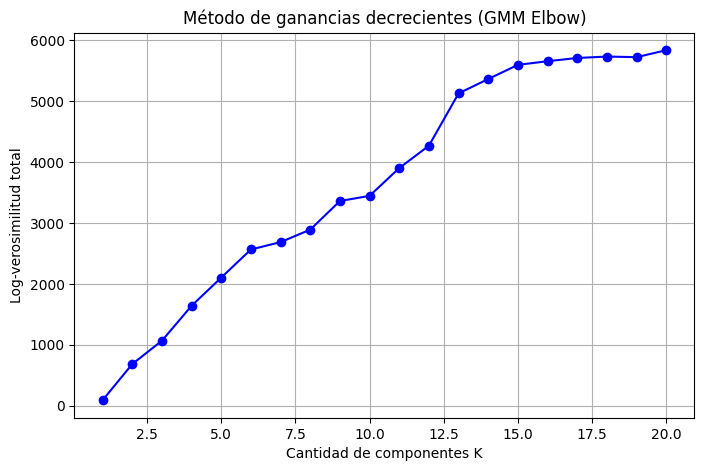

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Paso 2: Ejecutando GMM con K = 15...


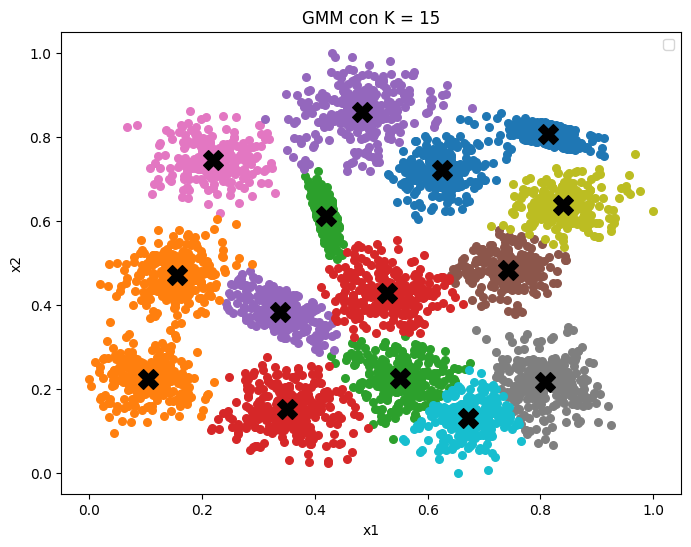

In [8]:
_=ejecutar_gmm_completo(X, k_max=20, k_final=15)

In [9]:
epsilons=np.linspace(0.01, 0.1, 20)
min_samples=np.linspace(5, 25, 10)
min_samples=min_samples.astype(int)
resultados=[]
for eps in epsilons:
    for min_sample in min_samples:
        
        print(f"eps: {eps}, min_samples: {min_sample}")
        dbscan = DBSCAN(eps=eps, min_samples=min_sample)
        dbscan.fit(X)
        labels = dbscan.predict(X)
        result=dbscan.score(X)
        resultados.append((eps, min_sample, result))


eps: 0.01, min_samples: 5
eps: 0.01, min_samples: 7
eps: 0.01, min_samples: 9
eps: 0.01, min_samples: 11
eps: 0.01, min_samples: 13
eps: 0.01, min_samples: 16
eps: 0.01, min_samples: 18
eps: 0.01, min_samples: 20
eps: 0.01, min_samples: 22
eps: 0.01, min_samples: 25
eps: 0.01473684210526316, min_samples: 5
eps: 0.01473684210526316, min_samples: 7
eps: 0.01473684210526316, min_samples: 9
eps: 0.01473684210526316, min_samples: 11
eps: 0.01473684210526316, min_samples: 13
eps: 0.01473684210526316, min_samples: 16
eps: 0.01473684210526316, min_samples: 18
eps: 0.01473684210526316, min_samples: 20
eps: 0.01473684210526316, min_samples: 22
eps: 0.01473684210526316, min_samples: 25
eps: 0.019473684210526317, min_samples: 5
eps: 0.019473684210526317, min_samples: 7
eps: 0.019473684210526317, min_samples: 9
eps: 0.019473684210526317, min_samples: 11
eps: 0.019473684210526317, min_samples: 13
eps: 0.019473684210526317, min_samples: 16
eps: 0.019473684210526317, min_samples: 18
eps: 0.01947368421

In [10]:
mejor_eps, mejor_min_sample, mejor_resultado = max(resultados, key=lambda x: x[2])
print(f"Mejor epsilon: {mejor_eps}, Mejor min_samples: {mejor_min_sample}, Mejor resultado: {mejor_resultado}")

Mejor epsilon: 0.024210526315789474, Mejor min_samples: 20, Mejor resultado: 0.5930840284652099


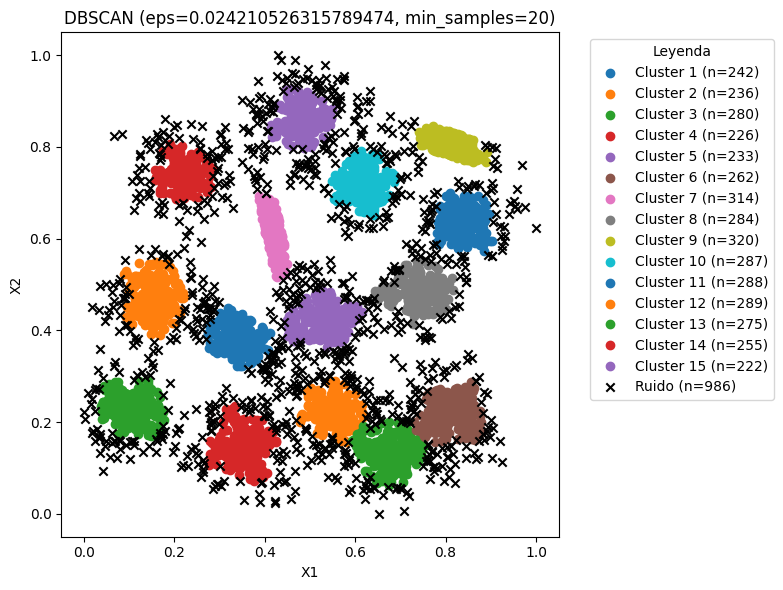

In [ ]:

epsilon=mejor_eps
min_points=mejor_min_sample

dbs = DBSCAN(eps=epsilon, min_samples=min_points)
dbs.fit(X)
labels = dbs.predict(X)
noise = labels == -1
plt.figure(figsize=(8,6))

unique_labels = sorted(set(labels))
for lab in unique_labels:
    if lab == -1:
        # lo reservamos para el ruido
        continue
    mask = labels == lab
    count = mask.sum()
    plt.scatter(X[mask, 0], X[mask, 1],
                marker='o',
                label=f'Cluster {lab} (n={count})')


# Graficar ruido

noise_count = noise.sum()
plt.scatter(X[noise, 0], X[noise, 1],
            c='k', marker='x',
            label=f'Ruido (n={noise_count})')

plt.title(f'DBSCAN (eps={epsilon}, min_samples={min_points})')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend(title="Leyenda", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/var/folders/cb/dbp_mbjn4r9_2hhc24flvgmw0000gn/T/ipykernel_15356/2761835403.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = cm.get_cmap('tab20', 20)  # hasta 20 colores distintos


Probando ε=0.01, min_samples=10
Probando ε=0.01, min_samples=15
Probando ε=0.01, min_samples=25
Probando ε=0.03, min_samples=10
Probando ε=0.03, min_samples=15
Probando ε=0.03, min_samples=25
Probando ε=0.04, min_samples=10
Probando ε=0.04, min_samples=15
Probando ε=0.04, min_samples=25


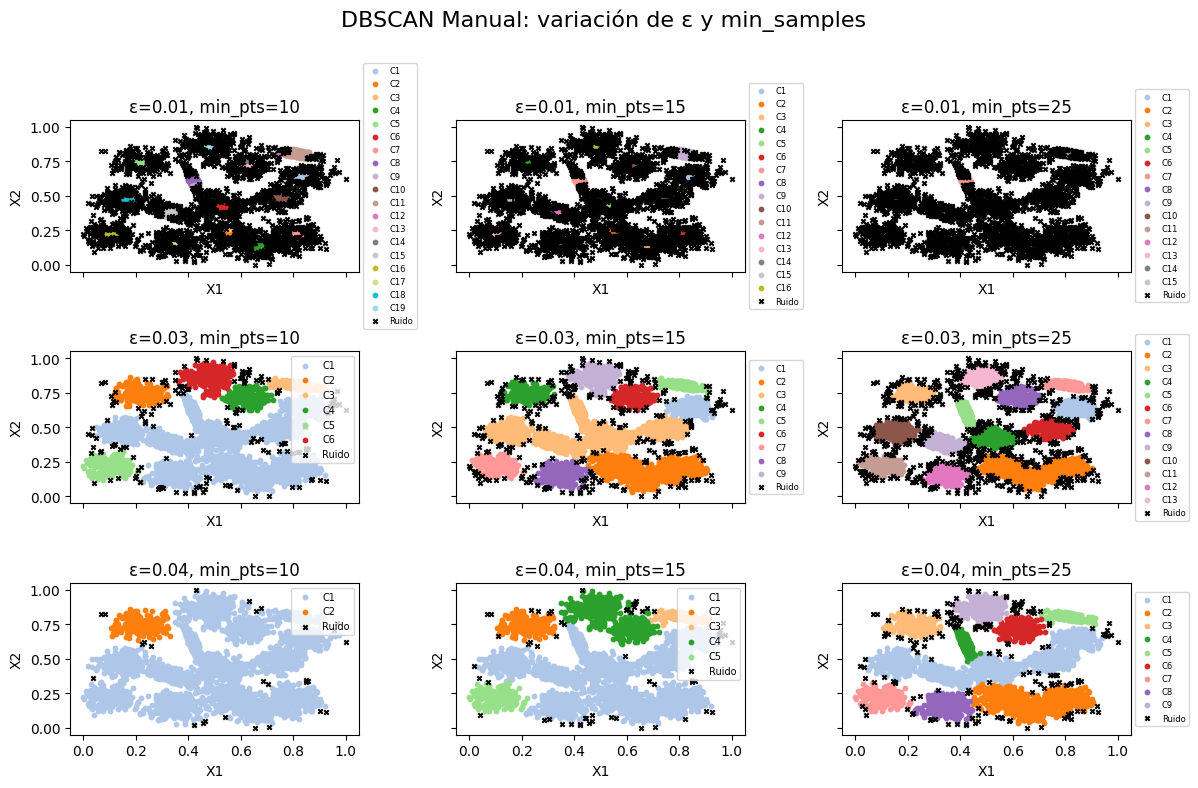

In [25]:

# Valores a probar
epsilons = [0.01, 0.03, 0.04]
min_points_vals = [10, 15, 25]

fig, axes = plt.subplots(3, 3, figsize=(12, 8), sharex=True, sharey=True)

# Paleta con suficientes colores
color_map = cm.get_cmap('tab20', 20)  # hasta 20 colores distintos

for i, eps in enumerate(epsilons):
    for j, min_pts in enumerate(min_points_vals):
        print(f"Probando ε={eps}, min_samples={min_pts}")
        ax = axes[i, j]
        
        # Ajustar DBSCAN manual
        dbs = DBSCAN(eps=eps, min_samples=min_pts)
        dbs.fit(X)
        labels = dbs.predict(X)
        noise = labels == -1

        unique_labels = sorted(set(labels))
        handles = []
        labels_text = []

        for lab in unique_labels:
            if lab == -1:
                continue
            mask = labels == lab
            color = color_map(lab % 20)
            sc = ax.scatter(X[mask, 0], X[mask, 1], s=10, c=[color], label=f'C{lab}')
            handles.append(sc)
            labels_text.append(f'C{lab}')

        # Ruido en negro con 'x'
        sc_noise = ax.scatter(X[noise, 0], X[noise, 1], c='k', marker='x', s=10)
        handles.append(sc_noise)
        labels_text.append('Ruido')

        ax.set_title(f"ε={eps}, min_pts={min_pts}")
        ax.set_xlabel('X1')
        ax.set_ylabel('X2')

        # Colocar leyenda a la derecha si hay muchos clusters
        if len(handles) <= 7:
            ax.legend(handles, labels_text, fontsize=7, loc='upper right')
        else:
            ax.legend(handles, labels_text, fontsize=6, loc='center left',
                      bbox_to_anchor=(1, 0.5), frameon=True)

plt.suptitle("DBSCAN Manual: variación de ε y min_samples", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

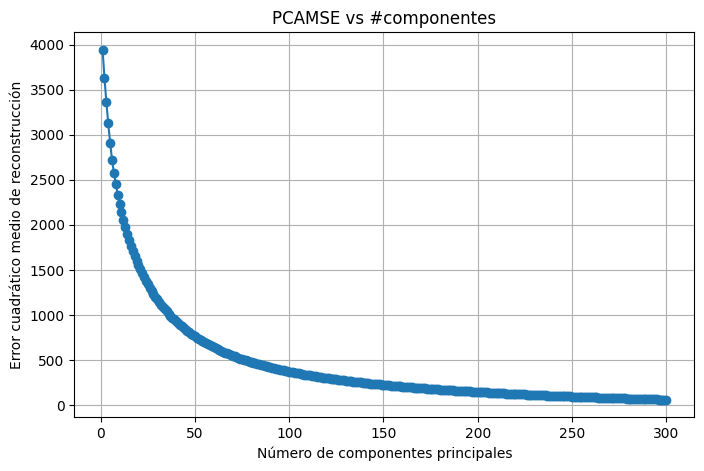

In [41]:

# Ejemplo de uso:
df = pd.read_csv('data/MNIST_dataset.csv')
X = df.values.astype(float)

pca = PCA().fit(X)
pca.plot_reconstruction_error(X, max_k=300)


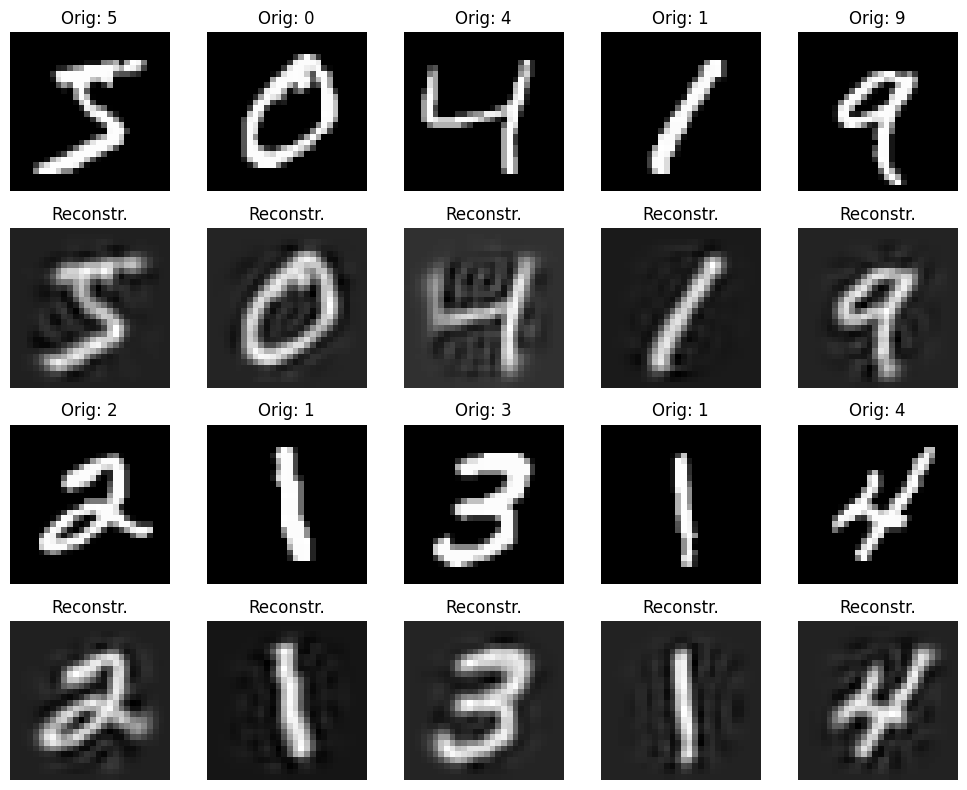

In [48]:
# 1) Cargar datos y separar etiquetas
df = pd.read_csv('data/MNIST_dataset.csv')  
y = df.iloc[:, 0].values               # etiquetas 0–9
X = df.iloc[:, 1:].values.astype(float)  # solo píxeles (784 columnas)
X = X / 255.0  # Normalizar a [0, 1]

# 2) Ajustar PCA manual
pca = PCA().fit(X)

# 3) Selección de componentes (e.g. k = 87)
k = 100
scores = pca.transform(X, k)
X_recon = pca.inverse_transform(scores)

# 4) Graficar originales vs reconstruidos (primeras 10 muestras) en 4 filas x 5 columnas
num = 10
filas = 4
columnas = 5

plt.figure(figsize=(2 * columnas, 2 * filas))

for i in range(num):
    fila_base = (i // columnas) * 2
    col = i % columnas

    # Imagen original
    ax1 = plt.subplot(filas, columnas, fila_base * columnas + col + 1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')
    ax1.set_title(f"Orig: {y[i]}")
    ax1.axis('off')

    # Imagen reconstruida
    ax2 = plt.subplot(filas, columnas, (fila_base + 1) * columnas + col + 1)
    plt.imshow(X_recon[i].reshape(28, 28), cmap='gray')
    ax2.set_title("Reconstr.")
    ax2.axis('off')

plt.tight_layout()
plt.show()


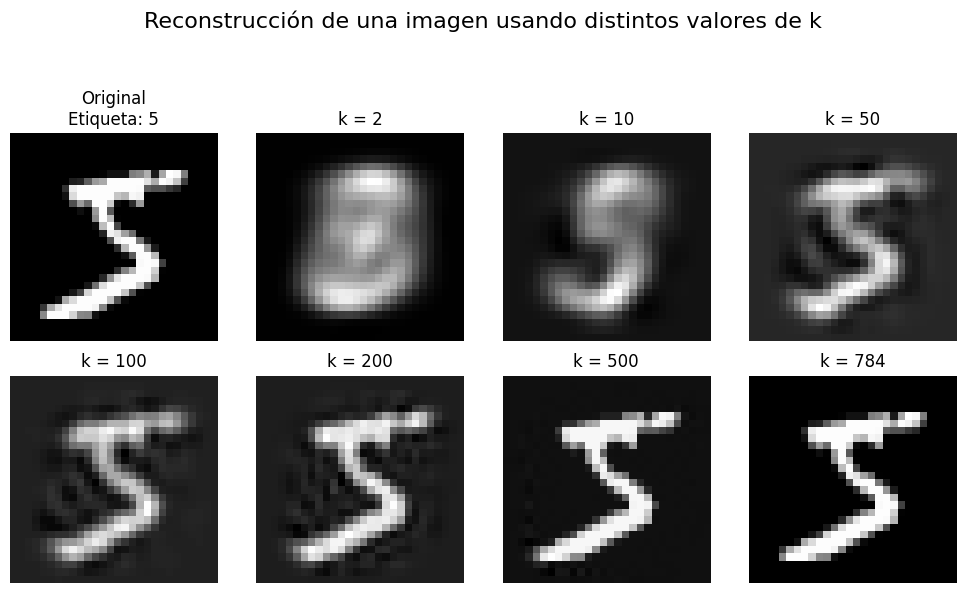

In [46]:
# Imagen base: primera muestra
img = X[0]
label = y[0]

# Valores de k a probar (número de componentes principales)
ks = [2, 10, 50, 100, 200, 500, 784]

# Proyectar y reconstruir para cada k
reconstrucciones = []
for k in ks:
    scores_k = pca.transform(img.reshape(1, -1), k)
    recon_k = pca.inverse_transform(scores_k)
    reconstrucciones.append((k, recon_k.reshape(28, 28)))

# Agregar imagen original al inicio
imagenes = [(None, img.reshape(28, 28))] + reconstrucciones

# Parámetros de la grilla
filas, columnas = 2, 4
plt.figure(figsize=(2.5 * columnas, 3 * filas))

for i, (k, imagen) in enumerate(imagenes):
    fila = i // columnas
    col = i % columnas
    ax = plt.subplot(filas, columnas, fila * columnas + col + 1)
    plt.imshow(imagen, cmap='gray')
    if k is None:
        ax.set_title(f"Original\nEtiqueta: {label}")
    else:
        ax.set_title(f"k = {k}")
    ax.axis('off')

# Celdas vacías (si sobran)
total_celdas = filas * columnas
for j in range(len(imagenes), total_celdas):
    ax = plt.subplot(filas, columnas, j + 1)
    ax.axis('off')

plt.suptitle("Reconstrucción de una imagen usando distintos valores de k", fontsize=16)

plt.subplots_adjust(hspace=0.7)  # <<--- este es el cambio que agrega espacio entre filas
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


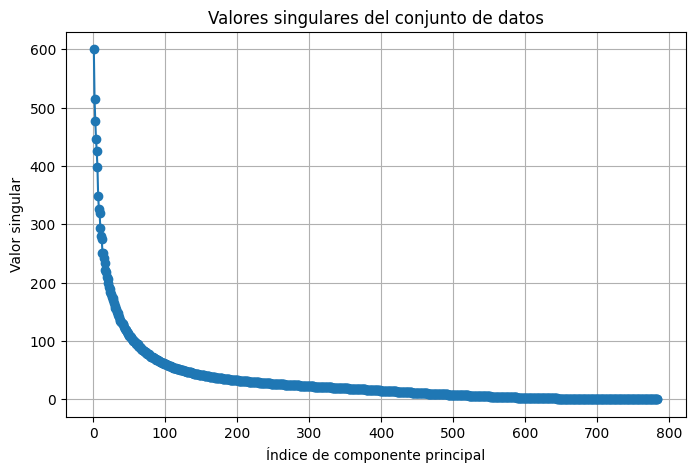

In [44]:
pca.plot_singular_values()